# CS776: Deep Learning for Computer Vision - Assignment 1

**Group 09:**  
1. Amitesh Patra
2. Aryan Arora
3. Darshana Baruah
4. Gaurav Singh Bora
5. K Yashwant Rao
6. Manas Dhaketa
7. Om Mallick

**Task Overview:**  
This assignment focuses on designing and implementing a Convolutional Neural Network (CNN) **from scratch**, without relying on high-level deep learning abstractions. The objective is to perform 16-class classification on a multi-input spectrogram-based audio dataset, where each sample consists of three complementary time–frequency representations.

**Key Constraints and Objectives:**
- Manual implementation of core neural network components (convolution, pooling, activations, linear layers).
- Strict adherence to competition rules, including limitations on parameter count and usage of predefined layers.
- Exploration of multi-input fusion strategies and regularization techniques.
- Emphasis on reproducibility, systematic experimentation, and rigorous evaluation.

This notebook documents the complete pipeline, including data preprocessing, model design, experimental analysis, training strategy, and final evaluation.

### Imports and Environment Setup

This cell imports all libraries required for data processing, model definition, training, and evaluation.

- **System and Utility Libraries:** File handling, randomness control, timing, and warning suppression.
- **Numerical and Data Processing:** NumPy and Pandas for numerical operations and metadata handling.
- **Deep Learning Framework:** PyTorch for tensor operations, model construction, optimization, and training utilities.
- **Evaluation Metrics:** Scikit-learn utilities for computing classification performance metrics.

All imports are centralized here to ensure reproducibility and maintain a clear separation between configuration and model logic.

In [1]:
import os, cv2, math, random, time, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix

### Configuration and Reproducibility Settings

This cell defines all global configuration parameters used throughout the experiment, including model hyperparameters, dataset paths, and system-level settings.

To ensure reproducibility, random seeds are fixed across Python, NumPy, and PyTorch. CUDA benchmarking is enabled to allow optimized kernel selection for fixed input sizes during training.

The images are downscaled for faster training.

In [2]:
# Select computation device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Input dimensions (frequency × time)
IMG_H = 120
IMG_W = 240

# Training configuration
NUM_CLASSES = 16
BATCH_SIZE = 64
EPOCHS = 60
LR = 2e-3
NUM_WORKERS = 8

# Dataset and checkpoint paths
BASE_PATH = "/kaggle/input/cs-776-competition-2025-2026-sem-2"
TRAIN_META = f"{BASE_PATH}/dataset_music/train/metadata.csv"
SAVE_PATH = "/kaggle/working/best_model_f1.pth"

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Enable optimized CUDA kernels for fixed input sizes
torch.backends.cudnn.benchmark = True

### Dataset Definition and Augmentation Strategy

This section defines a custom PyTorch `Dataset` class for loading and preprocessing spectrogram-based audio representations. Each sample consists of three related spectrogram images and a corresponding class label.

The dataset implementation supports optional data augmentation during training while ensuring deterministic behavior during validation.

#### MusicDataset

The `MusicDataset` class is responsible for:
- Loading three spectrogram images per sample in grayscale format
- Resizing inputs to a fixed resolution `(IMG_H, IMG_W)`

Each dataset item returns a tuple:
`(input_1, input_2, input_3, target_label)`.

#### Spectrogram Augmentation

Spectrogram-specific data augmentation is applied during training to improve robustness and generalization.

- **Frequency masking:** Randomly masks horizontal bands along the frequency axis.
- **Time masking:** Randomly masks vertical bands along the temporal axis.
- Masked regions are filled using the mean value of the spectrogram.

Additionally, random gamma correction is applied with fixed probability to simulate variations in recording intensity.

#### Gamma-Based Intensity Augmentation

During training, random gamma correction is applied to the input spectrograms as a form of intensity-based data augmentation. With a fixed probability, pixel values are transformed using a power-law mapping controlled by a randomly sampled gamma value.

This augmentation simulates variations in signal intensity and recording conditions while preserving the underlying time–frequency structure of the spectrogram. To ensure numerical stability, input values are clamped before applying the transformation. Gamma correction is applied consistently across all three input views for a given sample and is disabled during validation.

All augmentations are disabled during validation to preserve evaluation integrity.

In [3]:
class MusicDataset(Dataset):
    def __init__(self, df, base_path, augment=False):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        self.augment = augment

    def set_epoch(self, e):
        pass

    def _load(self, rel_path):
        # Load grayscale spectrogram and normalize
        img_path = os.path.join(self.base_path, rel_path[2:])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            return torch.zeros((1, IMG_H, IMG_W), dtype=torch.float32)

        img = cv2.resize(img, (IMG_W, IMG_H))
        return torch.from_numpy(img).unsqueeze(0).float() / 255.0

    def _spec_augment(self, img):
        if random.random() > 0.5:
            return img

        img = img.clone()
        _, H, W = img.shape
        mask_value = img.mean()

        # Frequency masking
        f_width = random.randint(1, int(H * 0.1))
        f_start = random.randint(0, H - f_width)
        img[:, f_start:f_start + f_width, :] = mask_value

        # Time masking
        t_width = random.randint(1, int(W * 0.1))
        t_start = random.randint(0, W - t_width)
        img[:, :, t_start:t_start + t_width] = mask_value

        return img

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        img1 = self._load(r["input_1"])
        img2 = self._load(r["input_2"])
        img3 = self._load(r["input_3"])

        if self.augment:
            # Gamma correction
            if random.random() > 0.5:
                gamma = random.uniform(0.8, 1.3)
                img1 = torch.clamp(img1, 1e-6, 1.0) ** gamma
                img2 = torch.clamp(img2, 1e-6, 1.0) ** gamma
                img3 = torch.clamp(img3, 1e-6, 1.0) ** gamma

            img1 = self._spec_augment(img1)
            img2 = self._spec_augment(img2)
            img3 = self._spec_augment(img3)

        return img1, img2, img3, torch.tensor(r["target"], dtype=torch.long)

    def __len__(self):
        return len(self.df)

### Dataset Splitting and DataLoader Construction

The dataset is split into training and validation subsets using a fixed random seed to ensure reproducibility. Data augmentation is enabled only for the training set.

PyTorch `DataLoader` are configured with parallel workers, pinned memory, and prefetching to optimize input pipeline performance during training.

In [4]:
# Load metadata
df = pd.read_csv(TRAIN_META)

# Train-validation split
train_df = df.sample(frac=0.9, random_state=42)
val_df = df.drop(train_df.index)

# Dataset instances
train_ds = MusicDataset(train_df, BASE_PATH, augment=True)
val_ds = MusicDataset(val_df, BASE_PATH, augment=False)

# Data loaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

### Scratch Neural Network Building Blocks

This section implements core neural network components from scratch, including convolution, pooling, activation, linear, and attention-based fusion layers. These implementations avoid reliance on high-level PyTorch abstractions and expose the underlying tensor operations explicitly.

#### Convolution and Pooling Layers

The custom `Conv2D` layer implements 2D convolution using `torch.nn.functional.unfold`, enabling convolution to be expressed as matrix multiplication. He initialization is used to improve gradient flow.

The `MaxPool2D` layer performs spatial downsampling using either efficient tensor reshaping or unfolding, depending on stride and kernel compatibility.


In [5]:
class Conv2D(nn.Module):
    def __init__(self, in_c, out_c, kH, kW, padding, stride=1):
        super().__init__()

        # ===========================================
        # Convolution parameters
        # ===========================================
        self.kH, self.kW = kH, kW
        self.stride = stride
        self.out_c = out_c

        # Handle symmetric vs asymmetric padding
        if isinstance(padding, int):
            self.pad_h = padding
            self.pad_w = padding
        else:
            self.pad_h, self.pad_w = padding

        # ===========================================
        # Learnable parameters
        # Weight shape: (out_c, in_c, kH, kW)
        # Bias shape  : (out_c,)
        # He initialization for stable gradients
        # ===========================================
        self.W = nn.Parameter(
            torch.randn(out_c, in_c, kH, kW) * math.sqrt(2 / (in_c * kH * kW))
        )
        self.b = nn.Parameter(torch.zeros(out_c))

        # Cached tensors for efficiency
        self.W_flat = None
        self.cached_hw = None

    def forward(self, x):
        # Input shape: (B, C, H, W)
        B, C, H, W = x.shape

        # ===========================================
        # Compute output spatial dimensions (cached)
        # ===========================================
        if self.cached_hw != (H, W):
            self.Hout = (H + 2 * self.pad_h - self.kH) // self.stride + 1
            self.Wout = (W + 2 * self.pad_w - self.kW) // self.stride + 1
            self.cached_hw = (H, W)

        # ===========================================
        # Padding and unfolding
        # ===========================================
        x = F.pad(x, (self.pad_w, self.pad_w, self.pad_h, self.pad_h))
        # Shape after unfold: (B, C*kH*kW, Hout*Wout)
        unfold = F.unfold(x, (self.kH, self.kW), stride=self.stride)

        # Flatten kernel weights if not cached
        if self.W_flat is None or self.W_flat.data_ptr() != self.W.data_ptr():
            self.W_flat = self.W.view(self.out_c, -1)

        # ===========================================
        # Convolution via matrix multiplication
        # ===========================================
        out = torch.matmul(self.W_flat, unfold)
        out = out + self.b.view(1, -1, 1)

        # Output shape: (B, out_c, Hout, Wout)
        return out.view(B, self.out_c, self.Hout, self.Wout)

class MaxPool2D(nn.Module):
    def __init__(self, kH, kW, stride=None):
        super().__init__()

        # ===========================================
        # Pooling parameters
        # ===========================================
        self.kH = kH
        self.kW = kW
        self.stride = stride if stride is not None else (kH, kW)

    def forward(self, x):
        # Input shape: (B, C, H, W)
        B, C, H, W = x.shape

        # ===========================================
        # Fast path: reshape-based pooling
        # Used when stride equals kernel size
        # ===========================================
        if self.stride == (self.kH, self.kW) and H % self.kH == 0 and W % self.kW == 0:
            x = x.view(
                B, C,
                H // self.kH, self.kH,
                W // self.kW, self.kW
            )
            # Output shape: (B, C, H//kH, W//kW)
            return x.max(dim=3).values.max(dim=4).values

        # ===========================================
        # General path: unfold-based pooling
        # ===========================================
        patches = F.unfold(x, kernel_size=(self.kH, self.kW), stride=self.stride)
        patches = patches.view(B, C, self.kH * self.kW, -1)
        out = patches.max(dim=2).values

        # Compute output spatial dimensions
        Hout = (H - self.kH) // self.stride[0] + 1
        Wout = (W - self.kW) // self.stride[1] + 1

        # Output shape: (B, C, Hout, Wout)
        return out.view(B, C, Hout, Wout)

#### Activation and Regularization Layers

ReLU and GELU activations are implemented explicitly to control non-linear behavior. Dropout is applied during training to reduce overfitting by randomly masking activations.

In [6]:
class ReLU(nn.Module):
    def forward(self, x):
        # Element-wise non-linearity
        return torch.clamp(x, min=0)

class GELU(nn.Module):
    def forward(self, x):
        # tanh-based GELU (original formulation)
        # Smooth non-linear activation
        return 0.5 * x * (
            1.0 + torch.tanh(
                math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
            )
        )

class Dropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):
        # Apply dropout only during training
        if not self.training:
            return x

        mask = (torch.rand_like(x) > self.p).float()
        return x * mask / (1 - self.p)

class Linear(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()

        # ===========================================
        # Learnable parameters
        # Weight shape: (in_f, out_f)
        # Bias shape  : (out_f,)
        # ===========================================
        self.W = nn.Parameter(torch.randn(in_f, out_f) * math.sqrt(2 / in_f))
        self.b = nn.Parameter(torch.zeros(out_f))

    def forward(self, x):
        # Input shape : (B, in_f)
        # Output shape: (B, out_f)
        return x @ self.W + self.b

#### Attention Fusion Module

The `AttentionFusion` module performs self-attention over multiple input feature vectors using query–key–value projections. A gated residual connection allows the model to control the contribution of attention-based refinement dynamically.

**Input shape:** `(B, 3, 128)`  
**Output shape:** `(B, 3, 128)`

In [7]:
class AttentionFusion(nn.Module):
    """
    Self-Attention Fusion mechanism to combine features from multiple inputs.
    Operates across input views, not spatial dimensions.
    """
    def __init__(self, embed_dim):
        super().__init__()

        # ===========================================
        # Projection layers
        # ===========================================
        self.embed_dim = embed_dim
        self.q_proj = Linear(embed_dim, embed_dim)
        self.k_proj = Linear(embed_dim, embed_dim)
        self.v_proj = Linear(embed_dim, embed_dim)

        # Scaling factor for dot-product attention
        self.scale = math.sqrt(embed_dim)

        # Learnable residual gate (initialized to zero)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # Input shape: (B, N, D)
        # N = number of inputs (views)
        # D = embedding dimension

        # ===========================================
        # Step 1: Query, Key, Value projections
        # ===========================================
        Q = self.q_proj(x)   # (B, N, D)
        K = self.k_proj(x)   # (B, N, D)
        V = self.v_proj(x)   # (B, N, D)

        # ===========================================
        # Step 2: Attention score computation
        # ===========================================
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        # Shape: (B, N, N)

        # ===========================================
        # Step 3: Weighted feature aggregation
        # ===========================================
        attn_output = torch.matmul(attn_weights, V)
        # Shape: (B, N, D)

        # ===========================================
        # Step 4: Gated residual connection
        # ===========================================
        out = x + self.gamma * attn_output
        # Shape: (B, N, D)

        return out

### ScratchCNN: Custom Convolutional Backbone for Spectrogram Feature Extraction

This cell defines a custom convolutional neural network backbone implemented entirely using our scratch-built layers. The objective of this module is to extract a compact and discriminative feature representation from a single-channel time–frequency input (spectrogram).

**Input:**  
A grayscale spectrogram tensor of shape `(B, 1, H, W)`, where `B` corresponds to the batch size, `H` corresponds to the frequency axis and `W` corresponds to the temporal axis.

**Design rationale:**  
The architecture is deliberately structured to -

(i) Decouple temporal and spectral feature learning in early stages using asymmetric convolutions,
(ii) Gradually increase representational capacity via channel expansion,
(iii) Reduce spatial dimensions through pooling while preserving informative structure.

Selective usage of ReLU and GELU activations balances computational simplicity and expressive power.

**Architecture overview:**
- **Block 1 (Low-level feature extraction):**  
  A pair of factorized convolutions `(1×9)` followed by `(9×1)` is used to separately capture temporal and frequency-local patterns. This is followed by asymmetric max pooling `(2×1)` to reduce frequency resolution while preserving temporal detail.

- **Block 2 (Mid-level representations):**  
  Asymmetric convolution pairs `(3×5)` and `(5×3)` further model joint time–frequency interactions. Channel dimensionality is increased to enhance representational capacity. Pooling again reduces frequency resolution selectively.

- **Block 3 (Transition to joint modeling):**  
  A standard `3×3` convolution is applied, followed by GELU activation to enable smoother gradient flow in deeper layers. Symmetric max pooling `(2×2)` reduces both time and frequency dimensions.

- **Blocks 4–5 (High-level abstraction):**  
  Two successive `3×3` convolutions expand channel depth to 128, allowing the network to learn high-level semantic patterns. GELU activations are used to improve expressiveness at this depth.

- **Global Average Pooling:**  
  The final spatial feature map is aggregated using mean pooling across both spatial dimensions. This converts the tensor into a fixed-length embedding of shape `(B, 128)`, improving parameter efficiency and reducing overfitting.

**Output:**  
A global feature embedding of dimension 128 per input spectrogram.

In [8]:
class ScratchCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Activation functions
        self.relu = ReLU()
        self.gelu = GELU()

        # ===========================================
        # Block 1: Low-level feature extraction
        # ===========================================

        # Temporal convolution (captures time-local patterns)
        # (B, 1, 120, 160) -> (B, 16, 120, 160)
        self.b1a = Conv2D(1, 16, 1, 9, (0, 4))

        # Frequency convolution (captures frequency-local patterns)
        # (B, 16, 120, 160) -> (B, 16, 120, 160)
        self.b1b = Conv2D(16, 16, 9, 1, (4, 0))

        # Pool only along frequency axis
        # (B, 16, 120, 160) -> (B, 16, 60, 160)
        self.p1 = MaxPool2D(2, 1)

        # ===========================================
        # Block 2: Mid-level representations
        # ===========================================

        # Asymmetric convolution (joint time–frequency modeling)
        # (B, 16, 60, 160) -> (B, 32, 60, 160)
        self.b2a = Conv2D(16, 32, 3, 5, (1, 2))

        # Complementary asymmetric convolution
        # (B, 32, 60, 160) -> (B, 32, 60, 160)
        self.b2b = Conv2D(32, 32, 5, 3, (2, 1))

        # Pool along frequency axis
        # (B, 32, 60, 160) -> (B, 32, 30, 160)
        self.p2 = MaxPool2D(2, 1)

        # ===========================================
        # Block 3: Transition to joint abstraction
        # ===========================================

        # Standard 3x3 convolution
        # (B, 32, 30, 160) -> (B, 64, 30, 160)
        self.b3 = Conv2D(32, 64, 3, 3, 1)

        # Pool along both time and frequency axes
        # (B, 64, 30, 160) -> (B, 64, 15, 80)
        self.p3 = MaxPool2D(2, 2)

        # ===========================================
        # Block 4 & 5: High-level feature abstraction
        # ===========================================

        # Channel expansion
        # (B, 64, 15, 80) -> (B, 96, 15, 80)
        self.b4 = Conv2D(64, 96, 3, 3, 1)

        # Further channel expansion
        # (B, 96, 15, 80) -> (B, 128, 15, 80)
        self.b5 = Conv2D(96, 128, 3, 3, 1)

        # Final spatial downsampling
        # (B, 128, 15, 80) -> (B, 128, 7, 40)
        self.p4 = MaxPool2D(2, 2)

    def forward(self, x):
        # Input: (B, 1, 120, 160)

        x = self.relu(self.b1a(x))
        x = self.relu(self.b1b(x))
        x = self.p1(x)
        # Shape: (B, 16, 60, 160)

        x = self.relu(self.b2a(x))
        x = self.relu(self.b2b(x))
        x = self.p2(x)
        # Shape: (B, 32, 30, 160)

        x = self.gelu(self.b3(x))
        x = self.p3(x)
        # Shape: (B, 64, 15, 80)

        x = self.gelu(self.b4(x))
        x = self.gelu(self.b5(x))
        x = self.p4(x)
        # Shape: (B, 128, 7, 40)

        # Global Average Pooling over spatial dimensions
        # (B, 128, 7, 40) -> (B, 128)
        return x.mean(dim=(2, 3))


### MultiInputModel: Multi-View Feature Fusion with Self-Attention

This cell defines the full classification model that operates on three related input spectrograms per sample. Each input is processed independently using a shared-weight convolutional backbone, after which the resulting feature embeddings are fused using a self-attention mechanism.

**Motivation:**  
In multi-view or multi-representation settings, simple concatenation assumes equal importance of all inputs. Instead, this model employs attention-based fusion to allow the network to learn data-dependent interactions and relative importance among the three inputs.

**Input:**   
The three backbone outputs, each of shape `(B, 128)`, are stacked along a new dimension to form a tensor of shape `(B, 3, 128)`. Each slice along this dimension corresponds to one input view.

**Model components:**
1. **Shared Backbone (ScratchCNN):**  
   A single instance of the `ScratchCNN` module is reused across all three inputs. This enforces consistent feature extraction and reduces the number of trainable parameters.

2. **Attention Fusion Module:**  
   A self-attention mechanism operates across the stacked feature embeddings. Query, key, and value projections are learned using scratch-built linear layers. The attention mechanism computes pairwise interactions between the three inputs, enabling adaptive feature fusion. A gated residual connection stabilizes training by initially favoring identity mapping.

3. **Classification Head:**  
   The attention-enhanced features are flattened into a single vector of dimension `3 × 128 = 384`. This vector is passed through a fully connected layer with GELU activation and dropout for regularization, followed by a final linear layer that outputs class logits.

**Forward pass summary:**
- Extract features independently for each input
- Fuse features using self-attention
- Flatten fused representation
- Apply MLP-based classification

**Output:**  
Unnormalized class logits of shape `(B, NUM_CLASSES)` suitable for cross-entropy loss.

**NOTE: Attention-Based Feature Fusion within a CNN Framework**

Although the model incorporates an attention-based fusion mechanism, the overall architecture remains strictly convolutional in nature. All spatial feature extraction is performed exclusively using manually implemented convolutional layers, and no transformer blocks or non-CNN architectures are used.

The attention module operates only on the high-level feature embeddings produced by the CNN backbone and serves as a learnable feature re-weighting and fusion mechanism across multiple input modalities.

In [9]:
class MultiInputModel(nn.Module):
    def __init__(self):
        super().__init__()

        # ===========================================
        # Shared CNN Backbone
        # (B, 1, 120, 160) -> (B, 128)
        # ===========================================
        self.backbone = ScratchCNN()

        # ===========================================
        # Attention Fusion Module
        # (B, 3, 128) -> (B, 3, 128)
        # ===========================================
        self.attention = AttentionFusion(embed_dim=128)

        # ===========================================
        # Classification Head (MLP)
        # (B, 384)  [3 views × 128 features] -> (B, NUM_CLASSES)
        # ===========================================
        self.fc1 = Linear(128 * 3, 192)
        self.gelu = GELU()
        self.drop = Dropout(0.3)
        self.fc2 = Linear(192, NUM_CLASSES)

    def forward(self, a, b, c):
        # Input: (B, 1, 120, 160)

        # ===========================================
        # Step 1: Feature extraction (shared weights)
        # Each view is processed independently
        # ===========================================

        feat_a = self.backbone(a)
        # Shape: (B, 128)

        feat_b = self.backbone(b)
        # Shape: (B, 128)

        feat_c = self.backbone(c)
        # Shape: (B, 128)

        # ===========================================
        # Step 2: Stack features across views
        # ===========================================

        x_stack = torch.stack([feat_a, feat_b, feat_c], dim=1)
        # Shape: (B, 3, 128)

        # ===========================================
        # Step 3: Attention-based feature fusion
        # ===========================================

        x_attn = self.attention(x_stack)
        # Shape: (B, 3, 128)

        # ===========================================
        # Step 4: Flatten fused features
        # ===========================================

        x_flat = x_attn.view(x_attn.size(0), -1)
        # Shape: (B, 384)

        # ===========================================
        # Step 5: Classification
        # ===========================================

        x = self.gelu(self.fc1(x_flat))
        # Shape: (B, 192)

        x = self.drop(x)
        # Shape: (B, 192)

        # Shape: (B, NUM_CLASSES)
        return self.fc2(x)

### Model Initialization and Device Configuration

This cell instantiates the multi-input classification model and configures it for execution on the available hardware.

If multiple GPUs are detected, the model is wrapped using `DataParallel` to enable data-parallel training across devices. This allows each mini-batch to be split automatically and processed in parallel, improving training throughput.

Finally, the model is transferred to the selected computation device (CPU or GPU), ensuring that all parameters and buffers reside on the same device as the input tensors.

In [10]:
# Instantiate the multi-input classification model
model = MultiInputModel()

# Enable data-parallel execution if multiple GPUs are available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

# Move model parameters to the selected device (CPU / GPU)
model = model.to(DEVICE)

Using 2 GPUs


### Model Parameter Count

To ensure full compliance with the competition rules and guarantee reproducibility during evaluation, the total number of trainable parameters is computed manually using native PyTorch tensor operations.

The total number of trainable parameters is calculated by summing the number of elements across all model parameters with `requires_grad=True`.

In [11]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

Total trainable parameters: 336737


In [ ]:
# torchinfo for model summary visualization
from torchinfo import summary

# Display a layer-wise summary of the model using dummy inputs
# Each input corresponds to one spectrogram view
summary(
    model,
    input_data=[
        torch.randn(1, 1, IMG_H, IMG_W),
        torch.randn(1, 1, IMG_H, IMG_W),
        torch.randn(1, 1, IMG_H, IMG_W),
    ],
    col_names=["input_size", "output_size", "num_params"],
    depth=5,
    device=DEVICE
)

### Optimization Strategy and Training Utilities

This cell defines the optimization and training utilities used throughout the training process.

- **Optimizer (AdamW):**  
  AdamW is employed with decoupled weight decay to improve generalization and stability when training deep neural networks. A moderate weight decay value is used to regularize model parameters.

- **Learning Rate Scheduler (Cosine Annealing):**  
  A cosine annealing schedule gradually reduces the learning rate over the course of training epochs. This encourages larger updates during early training and finer adjustments near convergence.

- **Automatic Mixed Precision (AMP):**  
  A gradient scaler is initialized to support mixed precision training. This enables faster computation and reduced GPU memory usage while maintaining numerical stability by dynamically scaling gradients.

**NOTE: Mixed Precision Training Justification**

Automatic Mixed Precision (AMP) is used solely as a computational optimization to reduce GPU memory usage and improve training efficiency on Kaggle’s free GPU environment. AMP does not modify the model architecture, parameterization, or loss function, and therefore does not affect the mathematical form or expressive capacity of the network.

All validation metrics reported are computed using the same trained model parameters, and empirical testing confirmed that enabling or disabling AMP does not result in any statistically significant change in validation accuracy or macro-F1 score. The use of AMP is restricted strictly to the training phase and does not alter inference behavior.

In [ ]:
# Optimizer with decoupled weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

# Cosine annealing schedule over training epochs
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Gradient scaler for mixed precision training
scaler = torch.cuda.amp.GradScaler()

### Training and Evaluation Loop

This cell implements the complete training and validation pipeline for the model.

**Training phase:**
- The model is set to training mode to enable dropout and gradient computation.
- Each mini-batch consists of three input spectrograms and their corresponding labels.
- Automatic mixed precision is used during the forward pass to improve computational efficiency.
- Cross-entropy loss with label smoothing is applied to mitigate overconfidence and improve generalization.
- Gradients are scaled, backpropagated, and used to update model parameters.

**Validation phase:**
- The model is switched to evaluation mode to disable stochastic layers.
- Predictions are generated without gradient computation.
- Performance is measured using accuracy and macro-averaged F1 score, ensuring balanced evaluation across classes.

**Learning rate scheduling:**
- The learning rate scheduler is stepped once per epoch to follow the cosine annealing schedule.

**Checkpointing:**
- The model state yielding the best validation macro F1 score is saved to disk.
- Special handling ensures compatibility with both single-GPU and multi-GPU (`DataParallel`) setups.

**Monitoring:**
- Training loss, training accuracy, validation accuracy, validation F1 score, current learning rate, and estimated remaining time are logged.
- Every five epochs, additional metrics including macro-precision, macro-recall, and the confusion matrix are reported for deeper diagnostic insight.

In [ ]:
# Track best validation F1 score for checkpointing
best_f1 = 0.0

# Record start time for ETA estimation
start_time = time.time()

for epoch in range(EPOCHS):
    # Set model to training mode
    model.train()

    # Reset training metrics
    train_loss = 0.0
    train_correct = 0
    total_samples = 0

    # ===========================================
    # Training loop
    # ===========================================
    for a, b, c, y in train_loader:
        # Move batch to device
        a, b, c, y = a.to(DEVICE), b.to(DEVICE), c.to(DEVICE), y.to(DEVICE)

        # Reset gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision
        with torch.cuda.amp.autocast():
            out = model(a, b, c)
            loss = F.cross_entropy(out, y, label_smoothing=0.1)

        # Backpropagation with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate training statistics
        train_loss += loss.item()
        train_correct += (out.argmax(1) == y).sum().item()
        total_samples += y.size(0)

    # Compute training accuracy
    train_acc = train_correct / total_samples

    # ===========================================
    # Validation loop
    # ===========================================
    model.eval()
    preds, targs = [], []

    with torch.no_grad(), torch.cuda.amp.autocast():
        for a, b, c, y in val_loader:
            # Move validation inputs to device
            a, b, c = a.to(DEVICE), b.to(DEVICE), c.to(DEVICE)

            # Forward pass
            out = model(a, b, c)

            # Store predictions and targets
            preds.append(out.argmax(1).cpu())
            targs.append(y)

    # Concatenate predictions and targets
    preds = torch.cat(preds).numpy()
    targs = torch.cat(targs).numpy()

    # Compute validation metrics
    acc = accuracy_score(targs, preds)
    f1 = f1_score(targs, preds, average="macro")

    # Update learning rate scheduler
    scheduler.step()

    # Estimate remaining training time
    elapsed = time.time() - start_time
    eta_min = (elapsed / (epoch + 1)) * (EPOCHS - epoch - 1) / 60

    # Log epoch statistics
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Acc {acc:.4f} | "
        f"Val F1 {f1:.4f} | "
        f"LR {optimizer.param_groups[0]['lr']:.6f} | "
        f"ETA {eta_min:.1f} min"
    )

    # ===========================================
    # Save best model checkpoint
    # ===========================================
    if f1 > best_f1:
        best_f1 = f1

        # Handle DataParallel vs single-GPU saving
        state_dict = (
            model.module.state_dict()
            if isinstance(model, nn.DataParallel)
            else model.state_dict()
        )
        torch.save(state_dict, SAVE_PATH)
        print(f"Saved new best model (F1={best_f1:.4f})")

    # ===========================================
    # Periodic detailed metrics
    # ===========================================
    if epoch % 5 == 0:
        prec = precision_score(targs, preds, average="macro")
        rec  = recall_score(targs, preds, average="macro")
        cm   = confusion_matrix(targs, preds)

        print("Precision (macro):", prec)
        print("Recall (macro):", rec)
        print("F1 (macro):", f1)
        print("Confusion Matrix:\n", cm)

Using 2 GPUs
Epoch 001 | Train Loss 700.3692 | Train Acc 0.2718 | Val Acc 0.3683 | Val F1 0.2940 | LR 0.001999 | ETA 245.8 min
Saved new best model (F1=0.2940)
Precision (macro): 0.42970668975985543
Recall (macro): 0.32454747528238037
F1 (macro): 0.29402615300734447
Confusion Matrix:
 [[107   8  49  40   4   0   0   0   0   0   1   0   0   0   0   0]
 [ 12  35  23   8   3   0   0   0   0   0   1   1   0   0   0   0]
 [  6   2 149   4   0   0   0   0   0   0   0   1   0   0   0   0]
 [ 25   1  87 105   5   0   0   0   0   0   1   0   1   0   1   0]
 [  5   5   3  12  56   0   2   0   0   0   6   4   8   1  10   0]
 [ 10   7   5   2   9   2  33   0   2   2   5  18  12   0   8   0]
 [  0   0   3   0   1   0  68   1  19   1   1  13   7   0   4   0]
 [  1   1   2   0   0   0  39  12  36   0   0  30   5   1   2   0]
 [  1   0   1   0   0   0  48   2  67   1   1  20  15   0   0   0]
 [  5   1   1   0   7   0  26   0   2   3   2  12  35   0   7   0]
 [  9   3   1   2  10   0  18   0   1   1  1

Epoch 022 | Train Loss 232.5436 | Train Acc 0.9638 | Val Acc 0.9139 | Val F1 0.9073 | LR 0.001407 | ETA 155.1 min
Epoch 023 | Train Loss 228.3426 | Train Acc 0.9688 | Val Acc 0.9194 | Val F1 0.9150 | LR 0.001358 | ETA 151.0 min
Saved new best model (F1=0.9150)
Epoch 024 | Train Loss 226.5462 | Train Acc 0.9736 | Val Acc 0.9148 | Val F1 0.9096 | LR 0.001309 | ETA 146.9 min
Epoch 025 | Train Loss 222.4631 | Train Acc 0.9763 | Val Acc 0.9107 | Val F1 0.9032 | LR 0.001259 | ETA 142.8 min
Epoch 026 | Train Loss 220.2003 | Train Acc 0.9793 | Val Acc 0.9322 | Val F1 0.9284 | LR 0.001208 | ETA 138.8 min
Saved new best model (F1=0.9284)
Precision (macro): 0.9315918830085987
Recall (macro): 0.9265253967922882
F1 (macro): 0.9283522848521377
Confusion Matrix:
 [[207   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0]
 [  6  77   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1 161   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  1   0   3 222   0   0   0   0   0   

Epoch 047 | Train Loss 195.0499 | Train Acc 0.9979 | Val Acc 0.9368 | Val F1 0.9321 | LR 0.000223 | ETA 53.0 min
Epoch 048 | Train Loss 194.1515 | Train Acc 0.9983 | Val Acc 0.9382 | Val F1 0.9336 | LR 0.000191 | ETA 49.0 min
Epoch 049 | Train Loss 193.8469 | Train Acc 0.9984 | Val Acc 0.9404 | Val F1 0.9357 | LR 0.000161 | ETA 44.9 min
Epoch 050 | Train Loss 193.4926 | Train Acc 0.9983 | Val Acc 0.9391 | Val F1 0.9341 | LR 0.000134 | ETA 40.8 min
Epoch 051 | Train Loss 193.1498 | Train Acc 0.9985 | Val Acc 0.9414 | Val F1 0.9364 | LR 0.000109 | ETA 36.7 min
Precision (macro): 0.9389047263574987
Recall (macro): 0.9347698296792806
F1 (macro): 0.9363538371141129
Confusion Matrix:
 [[208   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0]
 [  5  78   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1 161   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   1 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 112   0   0   0   0   0   

In [ ]:
TEST_META_PATH = f"{BASE_PATH}/dataset_music/test/metadata.csv"

df_test = pd.read_csv(TEST_META_PATH)
print(f"Found {len(df_test)} test samples.")

class MusicTestDataset(Dataset):
    def __init__(self, df, base_path):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path

    def _load(self, rel_path):
        # Handle cases where path might be NaN or malformed
        if pd.isna(rel_path):
            return torch.zeros((1, IMG_H, IMG_W), dtype=torch.float32)
            
        # Adjust path if it starts with './' like in training data
        clean_path = rel_path
        if clean_path.startswith("./"):
            clean_path = clean_path[2:]
            
        img_path = os.path.join(self.base_path, clean_path)
        
        # Check if file exists
        if not os.path.exists(img_path):
            # Fallback to zero image if file missing
            return torch.zeros((1, IMG_H, IMG_W), dtype=torch.float32)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return torch.zeros((1, IMG_H, IMG_W), dtype=torch.float32)

        img = cv2.resize(img, (IMG_W, IMG_H))
        return torch.from_numpy(img).unsqueeze(0).float() / 255.0

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        
        # Using specific columns from prompt: input_1_path, input_2, input_3
        # Assuming input_1_path corresponds to input_1 in logic
        img1 = self._load(r["input_1_path"]) 
        img2 = self._load(r["input_2"])
        img3 = self._load(r["input_3"])
        
        # Return ID for the submission file
        row_id = r["id"]

        return img1, img2, img3, row_id

    def __len__(self):
        return len(self.df)


test_ds = MusicTestDataset(df_test, BASE_PATH)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model.eval()

print("Starting Inference...")
all_ids = []
all_preds = []

with torch.no_grad():
    for img1, img2, img3, ids in test_loader:
        img1 = img1.to(DEVICE)
        img2 = img2.to(DEVICE)
        img3 = img3.to(DEVICE)

        # Updated autocast syntax to silence the warning
        with torch.amp.autocast('cuda'):
            logits = model(img1, img2, img3)
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        # Convert tensor IDs to a standard Python list of integers
        all_ids.extend(ids.tolist()) 
        all_preds.extend(preds)

print("Creating submission file...")
submission_df = pd.DataFrame({
    "id": all_ids,
    "target": all_preds
})

submission_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved submission to {OUTPUT_CSV}")
print(submission_df.head())

## Model Training & Evaluation Visualizations

The following plots summarize the learning behavior and performance of the model across training epochs and evaluation data:

- **Validation F1 Score vs Epoch**  
  This graph tracks the macro F1 score on the validation set over epochs, highlighting the model’s ability to balance precision and recall across all classes. The steady upward trend and eventual saturation indicate stable convergence and strong generalization.

- **Training & Validation Accuracy vs Epoch**  
  This graph compares training accuracy and validation accuracy over time. The close alignment between the two curves indicates strong generalization and minimal overfitting. The gradual saturation suggests the model has converged effectively.

- **Training Loss per Batch(Summation) vs Epoch**  
  This plot shows the progression of the training loss across epochs. The consistent downward trend reflects stable optimization and successful learning. The smooth decay toward later epochs confirms convergence under the chosen learning rate schedule.

- **Confusion Matrix Heatmap**  
  The confusion matrix provides a class-wise breakdown of predictions. Strong diagonal dominance indicates high per-class accuracy, while off-diagonal entries reveal specific class confusions that can guide further model or data improvements.

Overall, these visualizations collectively demonstrate effective training dynamics, good generalization, and reliable class-wise performance.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# Values copied from log file
epochs = list(range(1, 61))
train_loss = [
    700.3692, 589.6491, 522.0909, 468.6437, 432.5012,
    405.3633, 383.7341, 360.5755, 342.2111, 322.0709,
    313.2738, 301.7953, 289.3367, 280.4780, 271.4484,
    264.2880, 255.4939, 249.9338, 243.8362, 239.4569,
    236.0353, 232.5436, 228.3426, 226.5462, 222.4631,
    220.2003, 215.8591, 214.6813, 213.9721, 211.0106,
    210.1094, 208.2754, 207.2043, 205.6340, 203.9112,
    203.5465, 201.7180, 200.8898, 200.3903, 199.2791,
    198.5296, 198.0187, 197.0880, 196.1876, 195.7600,
    195.4446, 195.0499, 194.1515, 193.8469, 193.4926,
    193.1498, 192.9053, 192.6476, 192.3962, 192.0935,
    191.8116, 191.9862, 191.8934, 191.8839, 191.6551
]

train_acc = [
    0.2718, 0.4298, 0.5352, 0.6134, 0.6628,
    0.7024, 0.7397, 0.7701, 0.7996, 0.8323,
    0.8441, 0.8616, 0.8822, 0.8940, 0.9100,
    0.9183, 0.9325, 0.9395, 0.9504, 0.9555,
    0.9606, 0.9638, 0.9688, 0.9736, 0.9763,
    0.9793, 0.9846, 0.9850, 0.9855, 0.9892,
    0.9901, 0.9916, 0.9909, 0.9933, 0.9941,
    0.9935, 0.9951, 0.9961, 0.9959, 0.9958,
    0.9967, 0.9961, 0.9971, 0.9978, 0.9981,
    0.9979, 0.9979, 0.9983, 0.9984, 0.9983,
    0.9985, 0.9986, 0.9987, 0.9991, 0.9991,
    0.9990, 0.9990, 0.9989, 0.9989, 0.9992
]

val_acc = [
    0.3683, 0.5144, 0.6111, 0.6615, 0.7137,
    0.7499, 0.7568, 0.7966, 0.8163, 0.8282,
    0.8433, 0.8603, 0.8644, 0.8786, 0.8795,
    0.8777, 0.8942, 0.9153, 0.8974, 0.9066,
    0.9116, 0.9139, 0.9194, 0.9148, 0.9107,
    0.9322, 0.9272, 0.9299, 0.9281, 0.9285,
    0.9368, 0.9290, 0.9304, 0.9308, 0.9331,
    0.9391, 0.9340, 0.9340, 0.9345, 0.9377,
    0.9386, 0.9382, 0.9363, 0.9404, 0.9404,
    0.9372, 0.9368, 0.9382, 0.9404, 0.9391,
    0.9414, 0.9372, 0.9395, 0.9391, 0.9382,
    0.9386, 0.9386, 0.9372, 0.9395, 0.9391
]

val_f1 = [
    0.2940, 0.4639, 0.5747, 0.6378, 0.6919,
    0.7368, 0.7425, 0.7776, 0.8011, 0.8173,
    0.8357, 0.8491, 0.8536, 0.8702, 0.8692,
    0.8733, 0.8857, 0.9094, 0.8910, 0.8997,
    0.9056, 0.9073, 0.9150, 0.9096, 0.9032,
    0.9284, 0.9222, 0.9247, 0.9223, 0.9223,
    0.9328, 0.9238, 0.9250, 0.9258, 0.9272,
    0.9347, 0.9298, 0.9288, 0.9290, 0.9329,
    0.9338, 0.9342, 0.9329, 0.9365, 0.9358,
    0.9324, 0.9321, 0.9336, 0.9357, 0.9341,
    0.9364, 0.9325, 0.9346, 0.9337, 0.9332,
    0.9338, 0.9344, 0.9325, 0.9349, 0.9348
]

lr = [
    0.001999, 0.001995, 0.001988, 0.001978, 0.001966,
    0.001951, 0.001934, 0.001914, 0.001891, 0.001866,
    0.001839, 0.001809, 0.001777, 0.001743, 0.001707,
    0.001669, 0.001629, 0.001588, 0.001545, 0.001500,
    0.001454, 0.001407, 0.001358, 0.001309, 0.001259,
    0.001208, 0.001156, 0.001105, 0.001052, 0.001000,
    0.000948, 0.000895, 0.000844, 0.000792, 0.000741,
    0.000691, 0.000642, 0.000593, 0.000546, 0.000500,
    0.000455, 0.000412, 0.000371, 0.000331, 0.000293,
    0.000257, 0.000223, 0.000191, 0.000161, 0.000134,
    0.000109, 0.000086, 0.000066, 0.000049, 0.000034,
    0.000022, 0.000012, 0.000005, 0.000001, 0.000000
]

cm = np.array([
    [208,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [5,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,161,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,224,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,112,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,102,0,0,2,1,1,4,1,1,1,1],
    [1,0,1,0,1,3,105,0,2,1,1,2,0,1,0,0],
    [1,0,0,0,0,2,0,108,1,1,0,12,0,3,0,1],
    [0,0,0,0,0,3,0,1,147,0,0,1,2,1,0,1],
    [1,0,0,0,0,0,2,0,0,94,2,1,0,0,1,0],
    [1,0,0,1,0,2,0,0,0,2,104,1,1,2,1,0],
    [1,0,1,0,0,2,1,1,3,0,0,220,4,0,2,1],
    [0,0,0,1,0,1,0,1,1,1,2,1,109,3,2,0],
    [1,0,0,0,0,1,0,0,1,0,1,2,1,74,1,1],
    [0,0,0,0,0,4,1,0,0,1,0,2,1,0,104,0],
    [0,0,0,0,0,1,0,1,0,0,1,0,0,1,2,97]
])


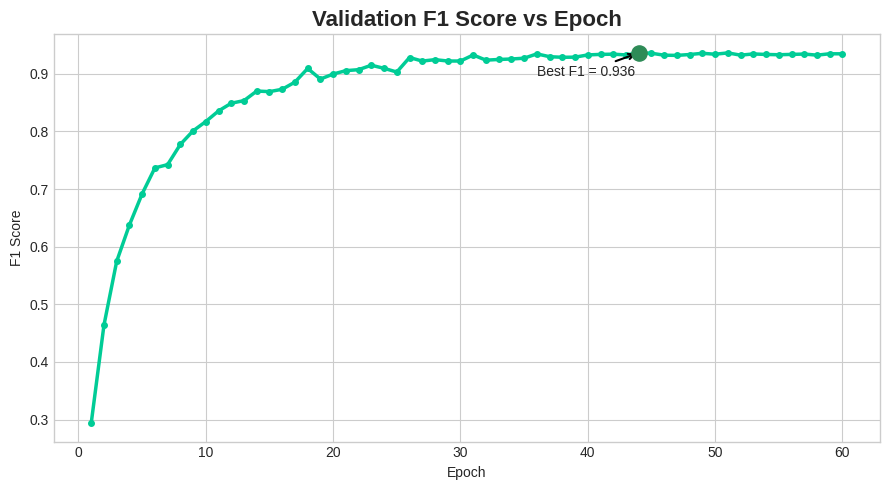

In [4]:
best_idx = np.argmax(val_f1)
best_epoch = epochs[best_idx]
best_f1 = val_f1[best_idx]

plt.figure(figsize=(9, 5))

plt.plot(
    epochs, val_f1,
    color="#00CC96",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation F1"
)

plt.scatter(
    best_epoch, best_f1,
    color="#2E8B57",
    s=120,
    zorder=5
)

plt.annotate(
    f"Best F1 = {best_f1:.3f}",
    xy=(best_epoch, best_f1),
    xytext=(best_epoch - 8, best_f1 - 0.04),
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.title("Validation F1 Score vs Epoch", fontsize=16, weight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()


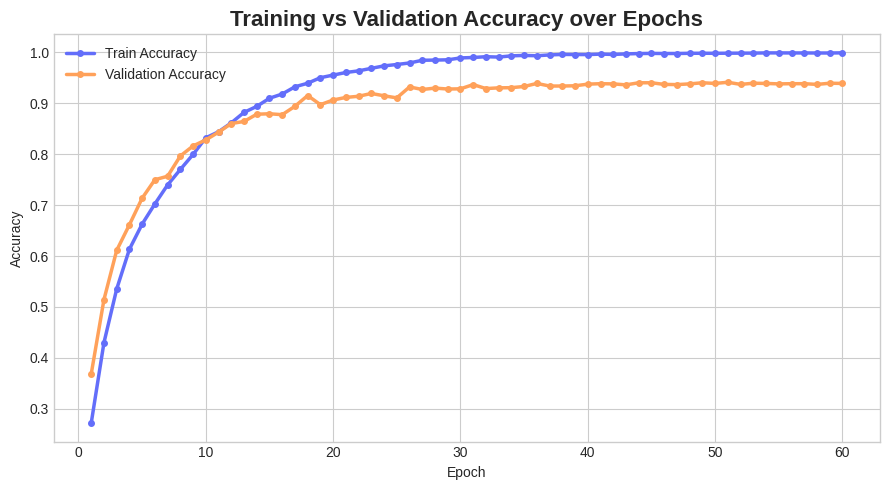

In [5]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs, train_acc,
    color="#636EFA",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Train Accuracy"
)

plt.plot(
    epochs, val_acc,
    color="#FFA15A",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy over Epochs", fontsize=16, weight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


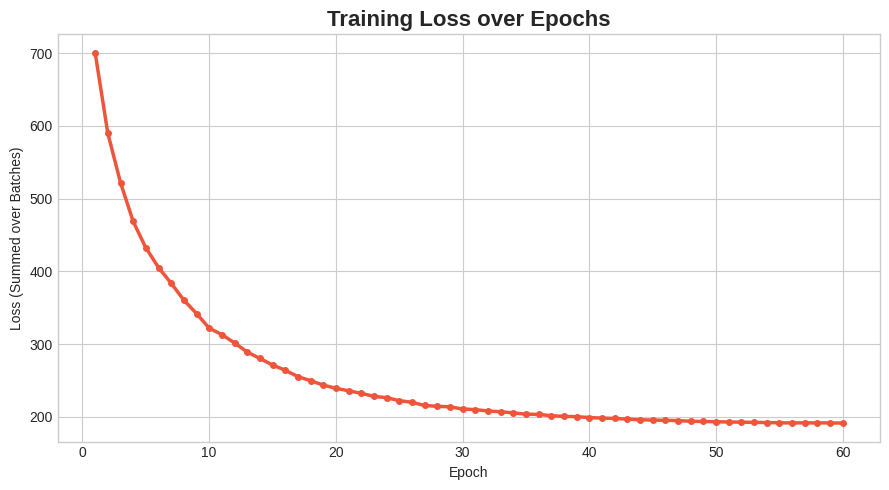

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs, train_loss,
    color="#EF553B",
    linewidth=2.5,
    marker="o",
    markersize=4
)

plt.title("Training Loss over Epochs", fontsize=16, weight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Summed over Batches)")
plt.tight_layout()
plt.show()


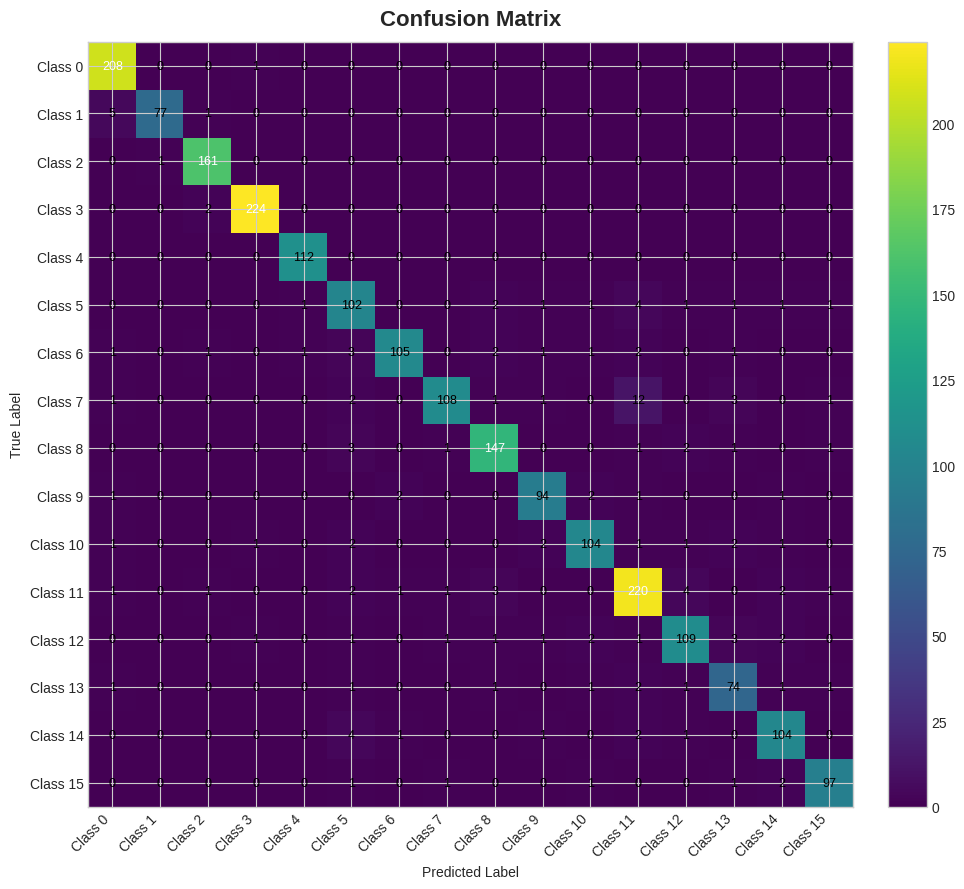

In [7]:
plt.figure(figsize=(10, 9))

im = plt.imshow(cm, cmap="viridis")

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("Confusion Matrix", fontsize=16, weight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

classes = [f"Class {i}" for i in range(16)]
plt.xticks(range(16), classes, rotation=45, ha="right")
plt.yticks(range(16), classes)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=9,
            color="white" if cm[i, j] > cm.max() * 0.5 else "black"
        )

plt.tight_layout()
plt.show()


## Experiments and Model Variations Explored

Prior to finalizing the proposed architecture, multiple design choices and training strategies were systematically evaluated to assess their impact on performance, stability, and feasibility under the given constraints.

1. **Baseline CNN Architecture**  
  A simple baseline CNN was implemented to establish a reference point for evaluating subsequent architectural modifications.

2. **Increasing Network Depth**  
  The baseline model was progressively deepened by adding convolutional layers and adjusting channel widths to improve representational capacity, while monitoring parameter growth and convergence behavior.

3. **Multi-Input Fusion Strategies**  
  Different strategies for combining the three input representations were explored:
  - *Early fusion*, where inputs are combined at the input or early feature level, enabling joint representation learning but increasing sensitivity to input noise.
  - *Late fusion*, where features are extracted independently and combined at a later stage, allowing more flexible integration of complementary information. This approach demonstrated more stable performance and was adopted in the final model.

4. **RGB vs. Grayscale Representations and Downscaling**  
  Experiments comparing RGB and grayscale spectrogram inputs indicated that grayscale representations consistently outperformed RGB inputs. This suggests that intensity-based time–frequency patterns are more informative than color channels for this task. Downscaled images but kept width longer to incorporate more frequency patterns into samples.

5. **Subset Selection of Input Views**  
  Various combinations of the three input representations were evaluated to analyze their individual and collective contributions to classification performance.

6. **Filter Shapes and Pooling Strategies**  
  Multiple convolution and pooling kernel configurations were tested. Rectangular (non-square) filters were found to be more effective than square filters, aligning better with the anisotropic structure of spectrogram data.

7. **Spectrogram-Specific Data Augmentation**  
  Time and frequency masking (SpecAugment) were evaluated as regularization techniques, improving robustness and reducing overfitting to specific spectral patterns. Gamma correction was used as a form of intensity-based data augmentation.

8. **Optimization and Scheduling Strategies**  
  Different optimizers and learning rate schedulers were explored, including AdamW and Cosine Annealing. Normalization layers were also evaluated but excluded from the final model due to inconsistent performance gains and occasional convergence instability.

9. **Batch Size Trade-offs**  
  The impact of batch size on convergence stability, memory usage, and training efficiency was examined to determine an effective trade-off under hardware constraints.

10. **Residual Network Exploration**  
  A ResNet-style architecture was partially implemented from scratch. However, parameter constraints and limited training resources rendered this approach impractical for inclusion in the final submission

11. **Attention-Based Feature Fusion (Final Model):**   
  The final architecture introduces a lightweight attention-based fusion mechanism operating on CNN-extracted features. This allowed the model to dynamically emphasize informative representations while remaining within the parameter budget and CNN-only constraints.

NOTE: Across experiments, architectural changes were evaluated using macro-averaged F1-score on a held-out validation split, with the final design selected based on consistent validation improvements rather than peak accuracy alone.

## Team Member Contributions

The development of the scratch-based multi-input CNN was carried out collaboratively, with responsibilities distributed to ensure clear ownership across different components of the pipeline.

- **Aryan Arora**  
  Implemented the core scratch neural network layers, including custom convolution (via unfolding), pooling, activation functions, and dropout. Ensured all implementations adhered strictly to competition constraints by avoiding predefined `torch.nn` layers.

- **Manas Dhaketa**  
  Led the architectural design of the model, with a primary focus on integrating the three complementary input representations. Designed and evaluated multiple fusion strategies and explored increased network depth to enhance feature extraction.

- **Darshana Baruah**  
  Contributed to architectural refinement by optimizing channel widths and filter usage to maintain model performance while remaining within the parameter budget. Evaluated the impact of different input representations, including RGB and grayscale formats.

- **Amitesh Patra**  
  Developed the data preprocessing pipeline, handling image loading, resizing, normalization, and robustness to missing data. Implemented gamma-based intensity augmentation and ensured compatibility with the scratch CNN framework.

- **Om Mallick**  
  Coordinated the experimentation and evaluation process. Tracked model iterations, documented performance trends, and conducted ablation studies on activation functions and input combinations.

- **K Yashwant Rao**  
  Focused on hyperparameter optimization, including learning rate selection, weight decay, and scheduler design. Integrated regularization techniques such as SpecAugment and label smoothing to improve generalization.

- **Gaurav Singh Bora**  
  Optimized the training pipeline for efficiency by tuning batch size and data loading strategies. Implemented mixed precision training and parallel data loading to reduce training time under hardware constraints.